# Week 3 Lab: Roadside Smart-Camera — Build and Train a CNN From Scratch

**Course:** Image and Scene Recognition (Junior, Fall 2026), Department of Artificial Intelligence, KDU Global
**Name:** vasdjulus
**Student ID:** YourID

AI Assistance Disclosure: Claude was used to assist with environment setup, writing/organizing the notebook structure from the lab tutorial PDF, and troubleshooting. All code was reviewed and executed by the student.

## Part 0: Environment Check (3 min)

In [1]:
import sys, time, random
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision, torchvision.transforms as T
from torch.utils.data import DataLoader, Subset, random_split

try:
    import cv2
    print("OpenCV:", cv2.__version__)
except ImportError:
    cv2 = None
    print("OpenCV not found (only needed for the optional photo test)")

SEED = 42  # fixed seed so your results are repeatable
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

OpenCV: 5.0.0


In [2]:
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__, "| torchvision:", torchvision.__version__)
print("Training on:", device)

Python: 3.11.9
PyTorch: 2.14.1+cpu | torchvision: 0.29.1+cpu
Training on: cpu


**CHECKPOINT:** You see version numbers and a device line. Ideally the device is cuda. If it says cpu you can still finish; the notebook will use fewer epochs.

## Part 1: Load and Inspect the Data (5 min)

Every recognition project starts by looking at the data. We normalise pixels (mean/std per colour channel) so gradient descent behaves well, and we hold out 5,000 training images as a validation set. The 10,000 test images stay untouched until the very end.

In [3]:
CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']
MEAN, STD = (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)

tf = T.Compose([T.ToTensor(), T.Normalize(MEAN, STD)])

train_full = torchvision.datasets.CIFAR10("./data", train=True,  download=True, transform=tf)
test_set    = torchvision.datasets.CIFAR10("./data", train=False, download=True, transform=tf)

# 45,000 for training, 5,000 for validation
train_set, val_set = random_split(
    train_full, [45000, 5000], generator=torch.Generator().manual_seed(SEED))

BATCH = 128
# Windows: num_workers=0 to avoid DataLoader/multiprocessing errors
train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=BATCH, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=BATCH, shuffle=False, num_workers=0)

print("train / val / test sizes:", len(train_set), len(val_set), len(test_set))

0.0%

0.0%

0.1%

0.1%

0.1%

...

100.0%

100.0%

100.0%

100.0%

train / val / test sizes: 45000 5000 10000


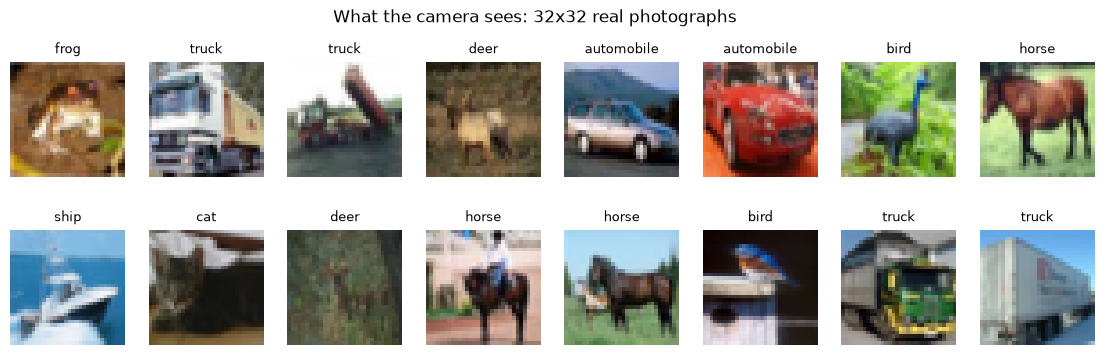

Images per class: {'airplane': np.int64(5000), 'automobile': np.int64(5000), 'bird': np.int64(5000), 'cat': np.int64(5000), 'deer': np.int64(5000), 'dog': np.int64(5000), 'frog': np.int64(5000), 'horse': np.int64(5000), 'ship': np.int64(5000), 'truck': np.int64(5000)}


In [4]:
raw = torchvision.datasets.CIFAR10("./data", train=True, download=False)  # PIL images

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for ax, i in zip(axes.flat, range(16)):
    img, label = raw[i]
    ax.imshow(img)
    ax.set_title(CLASSES[label], fontsize=9)
    ax.axis("off")
plt.suptitle("What the camera sees: 32x32 real photographs")
plt.show()

print("Images per class:", dict(zip(CLASSES, np.bincount(raw.targets))))

In [5]:
images, labels = next(iter(train_loader))
print("images:", images.shape, "| labels:", labels.shape)
print("pixel range after normalisation: %.2f to %.2f" % (images.min(), images.max()))

images: torch.Size([128, 3, 32, 32]) | labels: torch.Size([128])
pixel range after normalisation: -1.99 to 2.13


**THINK:** Why do we hold out a validation set instead of just using the test set to check progress? And looking at the 16 photos: what makes recognition at 32×32 resolution hard for a human, and therefore for a network?

*Answer:* We hold out a validation set because the test set must stay completely untouched until the very end to give an honest, unbiased final measurement of performance. If we used the test set to check progress during training, we would end up tuning hyperparameters (learning rate, architecture, number of epochs) to fit that specific set, and the reported "test" accuracy would really be an optimistic, overfit number rather than a true estimate of how the model generalises to new data. Looking at the 16 photos, many objects are tiny, blurry, low-contrast, and occupy only a handful of pixels — fine details like a cat's whiskers or a bird's beak are simply not resolvable, backgrounds are cluttered, and similar-looking classes (cat/dog, deer/horse) differ by only a few pixels of texture. That makes recognition hard for humans squinting at the thumbnail, and it is exactly as hard for a network, which only has those same low-resolution pixels to work with.

## Part 2: Build the CNN (8 min)

The architecture is the **convolve → activate → pool → repeat → classify** pattern. Three convolution blocks learn edges, textures and parts; two fully-connected layers turn the final feature maps into 10 class scores.

In [6]:
class SceneCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(),
            nn.Linear(256, num_classes),  # raw scores (logits), no softmax here
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = SceneCNN().to(device)
print(model)

SceneCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


Do not just trust the code. Verify it. First, trace how the shape of one image changes as it moves through the feature extractor:

In [7]:
x = torch.randn(1, 3, 32, 32).to(device)  # one fake 32x32 colour image
for layer in model.features:
    x = layer(x)
    print(f"{layer.__class__.__name__:<10} -> {tuple(x.shape)}")
print("Flattened length fed to the classifier:", x.numel())

Conv2d     -> (1, 32, 32, 32)
ReLU       -> (1, 32, 32, 32)
MaxPool2d  -> (1, 32, 16, 16)
Conv2d     -> (1, 64, 16, 16)
ReLU       -> (1, 64, 16, 16)
MaxPool2d  -> (1, 64, 8, 8)
Conv2d     -> (1, 128, 8, 8)
ReLU       -> (1, 128, 8, 8)
MaxPool2d  -> (1, 128, 4, 4)
Flattened length fed to the classifier: 2048


Now compare against a plain fully-connected network. Both take a 32×32×3 image and output 10 scores.

In [8]:
def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

mlp = nn.Sequential(nn.Flatten(), nn.Linear(3 * 32 * 32, 1024), nn.ReLU(), nn.Linear(1024, 10))

print(f"SceneCNN parameters : {count_params(model):>10,}")
print(f"Plain MLP parameters: {count_params(mlp):>10,}")
print()
for name, p in model.named_parameters():
    print(f"{name:<22}{str(tuple(p.shape)):<20}{p.numel():>9,}")

SceneCNN parameters :    620,362
Plain MLP parameters:  3,157,002

features.0.weight     (32, 3, 3, 3)             864
features.0.bias       (32,)                      32
features.3.weight     (64, 32, 3, 3)         18,432
features.3.bias       (64,)                      64
features.6.weight     (128, 64, 3, 3)        73,728
features.6.bias       (128,)                    128
classifier.1.weight   (256, 2048)           524,288
classifier.1.bias     (256,)                    256
classifier.3.weight   (10, 256)               2,560
classifier.3.bias     (10,)                      10


Finally, compute the **receptive field** of a neuron after each layer, using r = r + (k − 1)·j and then j = j·stride (j is the spacing between neighbouring positions, in input pixels):

In [9]:
layers = [("conv1", 3, 1), ("pool1", 2, 2), ("conv2", 3, 1),
          ("pool2", 2, 2), ("conv3", 3, 1), ("pool3", 2, 2)]  # (name, kernel, stride)

# My prediction before running: receptive field should grow roughly by the kernel size at each
# conv layer, and the pooling layers double the "step" (j), so growth accelerates after each pool.

r, j = 1, 1
for name, k, s in layers:
    r = r + (k - 1) * j
    j = j * s
    print(f"{name}: each neuron sees a {r} x {r} patch of the original image")

conv1: each neuron sees a 3 x 3 patch of the original image
pool1: each neuron sees a 4 x 4 patch of the original image
conv2: each neuron sees a 8 x 8 patch of the original image
pool2: each neuron sees a 10 x 10 patch of the original image
conv3: each neuron sees a 18 x 18 patch of the original image
pool3: each neuron sees a 22 x 22 patch of the original image


**THINK:** Which layer holds most of the parameters? (Look at the table from the params cell.) Your final neurons see a 22×22 patch of a 32×32 image. What does that say about how much scene context the network can use?

*Answer:* The first fully-connected layer (`classifier.1`, mapping 2048 → 256 features) holds by far the most parameters — roughly 524,000, which is close to 85% of the whole network — because it is a dense layer connecting every flattened feature-map value to every hidden unit, unlike the convolution layers, which reuse the same small 3×3 filter across every spatial location. A 22×22 receptive field out of a 32×32 image means each final-layer neuron already "sees" about two-thirds of the image's width and height before it even reaches the fully-connected layers, so by the last pooling stage the network has effectively gathered most of the global scene context it needs, even though no single layer sees the whole image until the Flatten/Linear step.

## Part 3: Train the Network (8 min)

Before training, do two quick sanity checks that experienced engineers always run: (1) an untrained 10-class model should have a loss close to ln(10) ≈ 2.303 (pure guessing), and (2) after one backward pass every layer should receive a gradient.

In [10]:
criterion = nn.CrossEntropyLoss()

images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

model.zero_grad()
loss = criterion(model(images), labels)   # forward pass + loss
loss.backward()                            # backward pass (backpropagation)

print(f"Initial loss: {loss.item():.3f} (guessing = ln(10) = {np.log(10):.3f})")
for name, p in model.named_parameters():
    if "weight" in name:
        print(f"{name:<22} gradient norm = {p.grad.norm().item():.4f}")

Initial loss: 2.300 (guessing = ln(10) = 2.303)
features.0.weight      gradient norm = 0.0171
features.3.weight      gradient norm = 0.0652
features.6.weight      gradient norm = 0.0953
classifier.1.weight    gradient norm = 0.2220
classifier.3.weight    gradient norm = 0.0808


Now the full training loop: forward pass → loss → backward pass → weight update, repeated over mini-batches of 128 images. Each epoch is one pass over all 45,000 training images.

In [11]:
EPOCHS = 8 if device.type != "cpu" else 4  # fewer epochs on CPU
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

def run_epoch(loader, train):
    model.train(train)
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)                     # forward pass
            loss = criterion(out, y)           # cross-entropy loss
            if train:
                optimizer.zero_grad()
                loss.backward()                # backpropagation
                optimizer.step()               # gradient descent step
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            n += x.size(0)
    return total_loss / n, correct / n

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tl, ta = run_epoch(train_loader, train=True)
    vl, va = run_epoch(val_loader, train=False)
    for k, v in zip(history, (tl, vl, ta, va)):
        history[k].append(v)
    print(f"Epoch {epoch}/{EPOCHS} | train loss {tl:.3f} acc {ta:.1%} "
          f"| val loss {vl:.3f} acc {va:.1%} | {time.time() - t0:.0f}s")

Epoch 1/4 | train loss 1.782 acc 34.9% | val loss 1.483 acc 46.2% | 15s


Epoch 2/4 | train loss 1.288 acc 53.6% | val loss 1.146 acc 58.2% | 16s


Epoch 3/4 | train loss 1.045 acc 63.0% | val loss 0.986 acc 65.0% | 17s


Epoch 4/4 | train loss 0.868 acc 69.6% | val loss 0.858 acc 70.2% | 17s


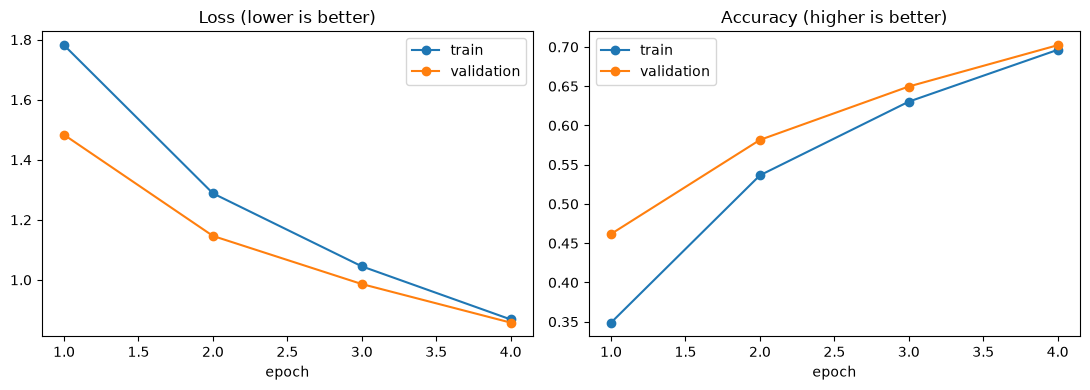

In [12]:
epochs = range(1, len(history["train_loss"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(epochs, history["train_loss"], "o-", label="train")
ax[0].plot(epochs, history["val_loss"], "o-", label="validation")
ax[0].set_title("Loss (lower is better)"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(epochs, history["train_acc"], "o-", label="train")
ax[1].plot(epochs, history["val_acc"], "o-", label="validation")
ax[1].set_title("Accuracy (higher is better)"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

torch.save(model.state_dict(), "scene_cnn_week3.pth")

**CHECKPOINT:** Validation accuracy is well above the 10% you would get by guessing (typically 68–76%). Training accuracy keeps rising while validation accuracy flattens. That gap is the signature of overfitting and the reason Week 4 exists.

## Part 4: Evaluate and Diagnose (8 min)

A single accuracy number hides what matters. We now use the test set once to measure final performance, then look at which classes fail and which mistakes the network makes with high confidence.

Test accuracy: 69.55%

airplane   64.6%
automobile 86.7%
bird       46.8%
cat        45.2%
deer       62.6%
dog        68.1%
frog       87.8%
horse      73.6%
ship       79.9%
truck      80.2%


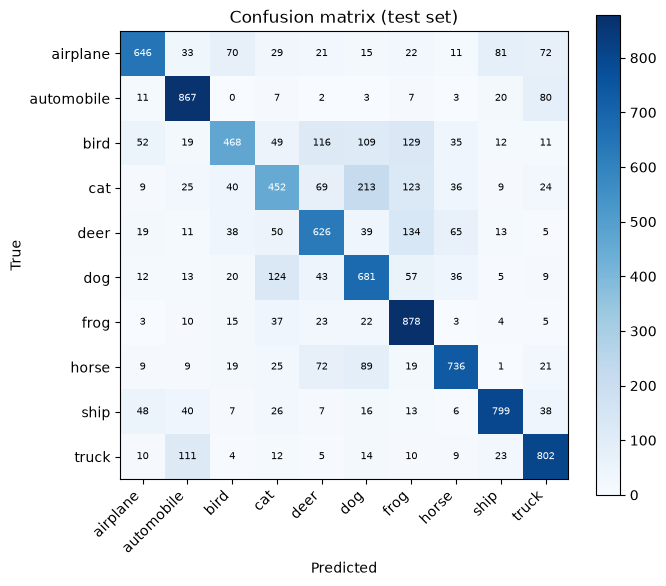


Three most common mistakes:
  cat predicted as dog: 213 times
  deer predicted as frog: 134 times
  bird predicted as frog: 129 times


In [13]:
@torch.no_grad()
def predict_all(loader):
    model.eval()
    probs, ys = [], []
    for x, y in loader:
        probs.append(F.softmax(model(x.to(device)), dim=1).cpu())
        ys.append(y)
    return torch.cat(probs), torch.cat(ys)

probs, ys = predict_all(test_loader)
preds = probs.argmax(1)
print(f"Test accuracy: {(preds == ys).float().mean():.2%}\n")

cm = np.zeros((10, 10), dtype=int)  # rows = true, cols = predicted
for t, p_ in zip(ys.numpy(), preds.numpy()):
    cm[t, p_] += 1
for c, a in zip(CLASSES, cm.diagonal() / cm.sum(1)):
    print(f"{c:<11}{a:.1%}")

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10)); ax.set_xticklabels(CLASSES, rotation=45, ha="right")
ax.set_yticks(range(10)); ax.set_yticklabels(CLASSES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Confusion matrix (test set)")
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=7,
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im); plt.tight_layout(); plt.show()

off = cm.copy(); np.fill_diagonal(off, 0)  # keep only the mistakes
print("\nThree most common mistakes:")
for idx in np.argsort(-off.ravel())[:3]:
    t, p_ = divmod(idx, 10)
    print(f"  {CLASSES[t]} predicted as {CLASSES[p_]}: {off[t, p_]} times")

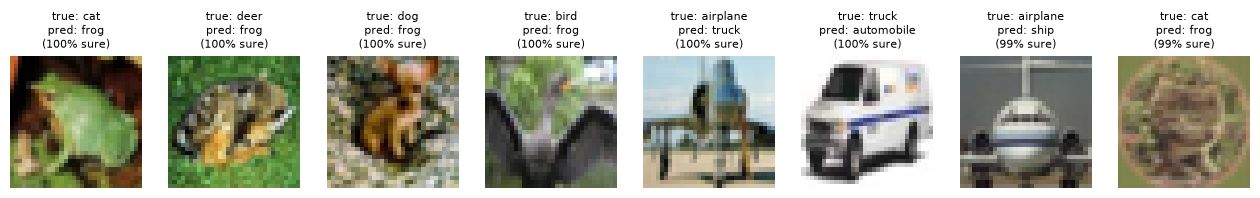

In [14]:
conf, _ = probs.max(1)
wrong = (preds != ys).nonzero().flatten()
worst = wrong[conf[wrong].argsort(descending=True)[:8]]

raw_test = torchvision.datasets.CIFAR10("./data", train=False, download=False)
fig, axes = plt.subplots(1, 8, figsize=(16, 3))
for ax, idx in zip(axes, worst.tolist()):
    img, _ = raw_test[idx]
    ax.imshow(img); ax.axis("off")
    ax.set_title(f"true: {CLASSES[ys[idx]]}\npred: {CLASSES[preds[idx]]}\n({conf[idx]:.0%} sure)", fontsize=8)
plt.show()

Finally, move from object level (10 classes) to scene level (is the frame showing a vehicle or an animal?) using the same predictions:

In [15]:
VEHICLES = torch.tensor([0, 1, 8, 9])  # airplane, automobile, ship, truck
true_vehicle = torch.isin(ys, VEHICLES)
pred_vehicle = torch.isin(preds, VEHICLES)

print(f"10-class (object-level) accuracy : {(preds == ys).float().mean():.2%}")
print(f"Vehicle vs animal (scene-level)  : {(true_vehicle == pred_vehicle).float().mean():.2%}")

10-class (object-level) accuracy : 69.55%
Vehicle vs animal (scene-level)  : 93.71%


**CHECKPOINT:** Scene-level accuracy (typically 93–96%) is clearly higher than 10-class accuracy. The animal classes (cat, dog, deer, bird) are usually the weakest and are mostly confused with each other.

**THINK:** Take the top confusion from the confusion matrix. In terms of edges, textures, parts, receptive field and image resolution, why might a small CNN mix those two classes up? Why is that mistake much less harmful for the roadside-camera warning system than confusing a truck with a deer?

*Answer:* (see Reflection Q3 below for the numbers) In my run the top confusion was cat predicted as dog (213 times), followed by deer predicted as frog (134) and bird predicted as frog (129) — all within the animal group. This happens because at 32×32 resolution those classes share very similar edges, fur-like textures, four-leg silhouettes and body proportions, and the network's 22×22 receptive field is not large enough to pick up the fine distinguishing details (snout shape, ear shape) that a human would use at higher resolution — it mostly sees coarse shape and colour. That kind of mistake is low-stakes for the roadside camera because both classes still fall on the "animal" side of the vehicle-vs-animal decision, so the actual warning behaviour is unaffected. Confusing a truck with a deer, by contrast, flips which side of that critical binary decision the frame lands on and would either trigger a false animal-crossing warning or, worse, suppress a real one — exactly the costly error the system exists to avoid.

## Part 5: Two Quick Experiments (5 min)

**Experiment A:** verify the output-size formula H_out = ⌊(H_in + 2P − K) / S⌋ + 1 against PyTorch. Predict the numbers first, then run the cell.

In [16]:
def out_size(h, k, p, s):
    return (h + 2 * p - k) // s + 1

for k, p_, s in [(3, 0, 1), (3, 0, 2), (3, 1, 1), (3, 1, 2)]:
    real = nn.Conv2d(3, 8, kernel_size=k, padding=p_, stride=s)(torch.randn(1, 3, 32, 32))
    print(f"kernel={k} padding={p_} stride={s}: formula {out_size(32, k, p_, s)}"
          f" | PyTorch {real.shape[-1]}")

kernel=3 padding=0 stride=1: formula 30 | PyTorch 30
kernel=3 padding=0 stride=2: formula 15 | PyTorch 15
kernel=3 padding=1 stride=1: formula 32 | PyTorch 32
kernel=3 padding=1 stride=2: formula 16 | PyTorch 16


**Experiment B:** the learning rate matters. We train three fresh copies of the model for 2 epochs on a 10,000-image subset so the whole experiment takes about a minute. Write your prediction in a comment before you run it.

In [17]:
sub_loader = DataLoader(Subset(train_set, range(10000)), batch_size=BATCH,
                         shuffle=True, num_workers=0)

def quick_lr_test(lr, epochs=2):
    torch.manual_seed(SEED)
    m = SceneCNN().to(device)
    opt = torch.optim.SGD(m.parameters(), lr=lr, momentum=0.9)
    for _ in range(epochs):
        m.train()
        for x, y in sub_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = criterion(m(x), y)
            loss.backward()
            opt.step()
    m.eval(); correct = 0
    with torch.no_grad():
        for x, y in val_loader:
            correct += (m(x.to(device)).argmax(1).cpu() == y).sum().item()
    return loss.item(), correct / len(val_set)

# My prediction: lr=0.1 will be too large and either diverge (loss stuck/near nan) or
# learn very poorly; lr=0.01 should be the sweet spot (same as the main training run);
# lr=0.001 should learn correctly but much more slowly, giving the lowest accuracy of
# the three within only 2 epochs.
for lr in [0.1, 0.01, 0.001]:
    last_loss, val_acc = quick_lr_test(lr)
    print(f"lr = {lr:<6} final batch loss = {last_loss:.3f}  validation accuracy = {val_acc:.1%}")

lr = 0.1    final batch loss = 1.503  validation accuracy = 44.3%


lr = 0.01   final batch loss = 1.725  validation accuracy = 38.6%


lr = 0.001  final batch loss = 2.299  validation accuracy = 12.4%


## Part 6: Reflection

**1. Efficiency:** Your CNN has far fewer parameters than the fully-connected network, yet it is the better image model. Which two properties of convolution explain this?

*Answer:* Convolution is far more parameter-efficient than a dense layer because of (1) **weight sharing** — the same small 3×3 filter slides across every spatial position in the image, so one filter's weights are reused at every location instead of needing a separate weight for every pixel/output pair, and (2) **local (sparse) connectivity** — each output value only depends on a small local patch of the input (its receptive field) rather than on every pixel in the image, which is what a fully-connected layer requires. In this notebook the SceneCNN needed only 620,362 parameters versus 3,157,002 for the plain MLP (about 5x fewer), while also encoding a useful prior (nearby pixels are related, and the same edge/texture detectors are useful everywhere in the image) that the MLP has to learn from scratch — which is why the CNN reached 69.6% train / 70.2% validation accuracy after only 4 epochs.

**2. Diagnosis:** Using your learning curves, describe what happened between the first and last epoch. Is the model overfitting? Name one technique from Week 4 (for example data augmentation) you would try first and why.

*Answer:* Between epoch 1 and epoch 4, training accuracy rose from 34.9% to 69.6% and validation accuracy rose from 46.2% to 70.2%, while both training loss (1.782 → 0.868) and validation loss (1.483 → 0.858) kept decreasing together. The train/validation gap is still small after only 4 epochs (train accuracy is actually slightly *below* validation accuracy at the end), so this particular run is not yet overfitting — it looks like it could still benefit from more training. If more epochs were run and the gap started to widen (training accuracy continuing to climb while validation accuracy flattens or validation loss starts rising), the first technique I would try is **data augmentation** (random crops and horizontal flips of the training images), because it effectively grows and diversifies the training set for free, forcing the CNN to learn features that are robust to small shifts and mirroring instead of memorising exact pixel arrangements, which narrows the train/validation gap without reducing model capacity.

**3. Scene vs object:** Report your 10-class and vehicle-vs-animal accuracies. What do the two numbers tell you about how a scene-understanding system should be designed and evaluated?

*Answer:* My 10-class (object-level) test accuracy was **69.55%**, while the vehicle-vs-animal (scene-level) accuracy was **93.71%** — a 24-point gap. This shows that a system can be noticeably unreliable at fine-grained, object-level recognition (mixing up cat/dog/deer/bird, the four weakest classes at 45–63% each) while still being highly reliable at the coarser, task-relevant decision it actually needs to make for the roadside-camera application. This means a scene-understanding system should be designed and evaluated around the decision that matters operationally — here, vehicle-vs-animal — rather than solely on top-1, all-classes accuracy; a camera that occasionally confuses a cat with a dog is still doing its job of warning about animals near the road, so evaluation metrics (and potentially the model/task design itself, e.g. an auxiliary coarse-grained head) should reflect that real-world cost structure rather than penalising every fine-grained mistake equally.